# Metastasis (R9): DCIS → IDC → metastasis → treatment

This notebook shows the metastasis module on the shared ductal-field substrate (`base_sim`). A
single tumour is grown through the **full clinical arc** and every panel is ground truth:

1. **grow** a multi-focal DCIS→IDC lesion on the primary duct field;
2. **seed** a metastatic deposit — a *second deme-grid* reached by an invasion-gated migration
   operator (only cancer that has invaded the stroma can seed), sharing ONE genealogy with the
   primary, and enriched at the transit bottleneck for a heritable `met_survival` trait;
3. **resect** the primary (all its cells removed; the simulation continues on the met);
4. **systemic chemo**, run until the *susceptible* clones are eliminated — its toxicity also kills
   off-target **normal tissue**;
5. **relapse** of the surviving *resistant* clones.

The metastasis is founded by a **bottlenecked, transit-selected, usually-minor** primary clone, so
the met's clonal make-up is a non-representative sample of the primary — the confound the two
compartment views below expose.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import base_sim as bs

# grow → seed → resect → chemo (until susceptible gone) → relapse
t, marks = bs.grow_metastasis_tumor(seed=3)
mk = [(marks.get('seeding', 0), 'seeding'), (marks['resection'], 'resection'),
      (marks['chemo_start'], 'chemo'), (marks['chemo_end'], 'chemo off')]
print('primary cancer:', bs.compartment_cancer(t)[0], ' met cancer:', bs.met_cancer(t),
      ' (susceptible:', bs.met_cancer(t, False), ' resistant:', bs.met_cancer(t, True), ')')

primary cancer: 0  met cancer: 2353  (susceptible: 18  resistant: 2335 )


## The two compartments in space
The primary duct field (multi-focal DCIS cores invading into stroma) and the metastatic deposit
(a single vessel-centred mass expanding into host tissue), coloured by per-deme cancer fraction.

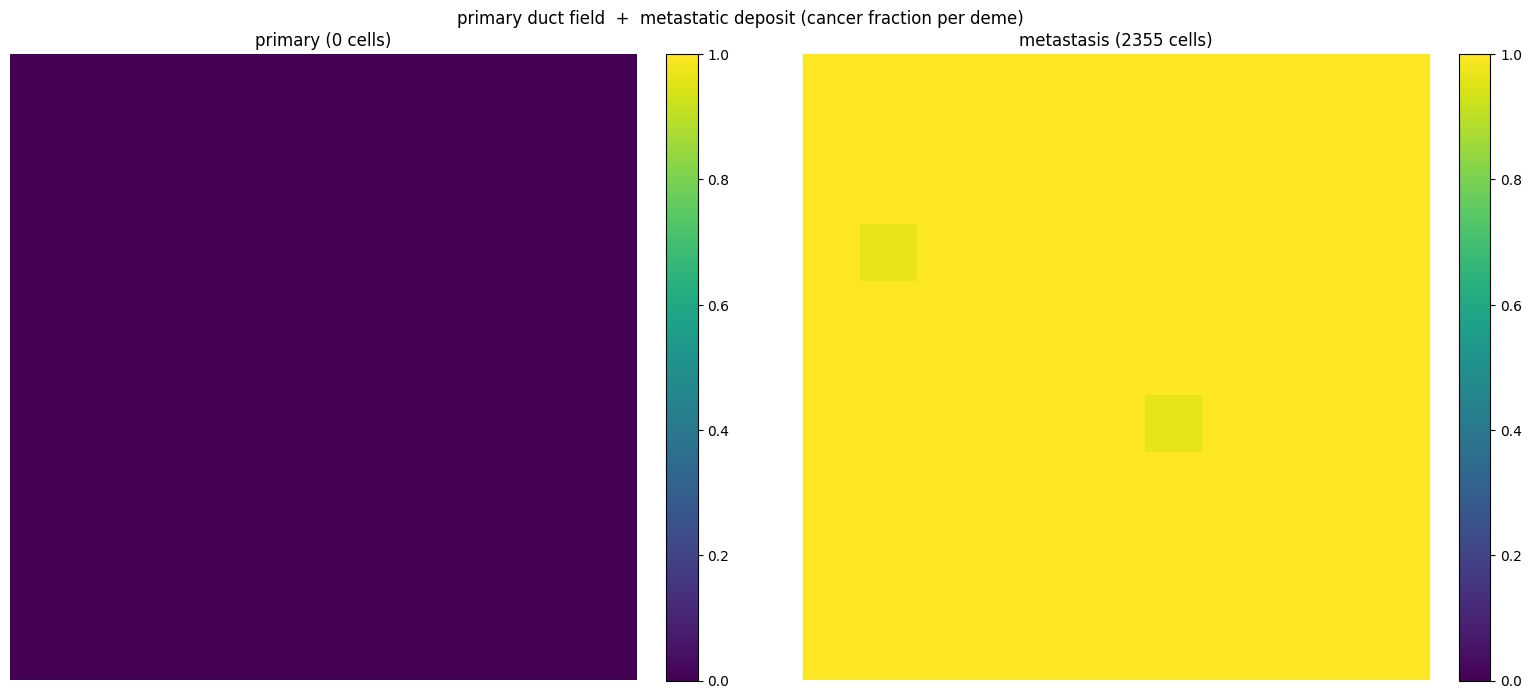

In [2]:
t.plot_grid_compartments(color=['cancer_frac'])
plt.suptitle('primary duct field  +  metastatic deposit (cancer fraction per deme)')
plt.tight_layout(); plt.show()

## The clonal arc — 2-band Muller (functional clones, shared colours)
Primary (top) and metastasis (bottom) share ONE functional-clone colour map. The primary collapses
at resection; the met regresses under chemo then **relapses from resistant clones**. The ⭐ marks
the clone that seeded the met, in **both** panels at the seeding moment — a specific (minor)
primary clone whose descendants found the deposit.

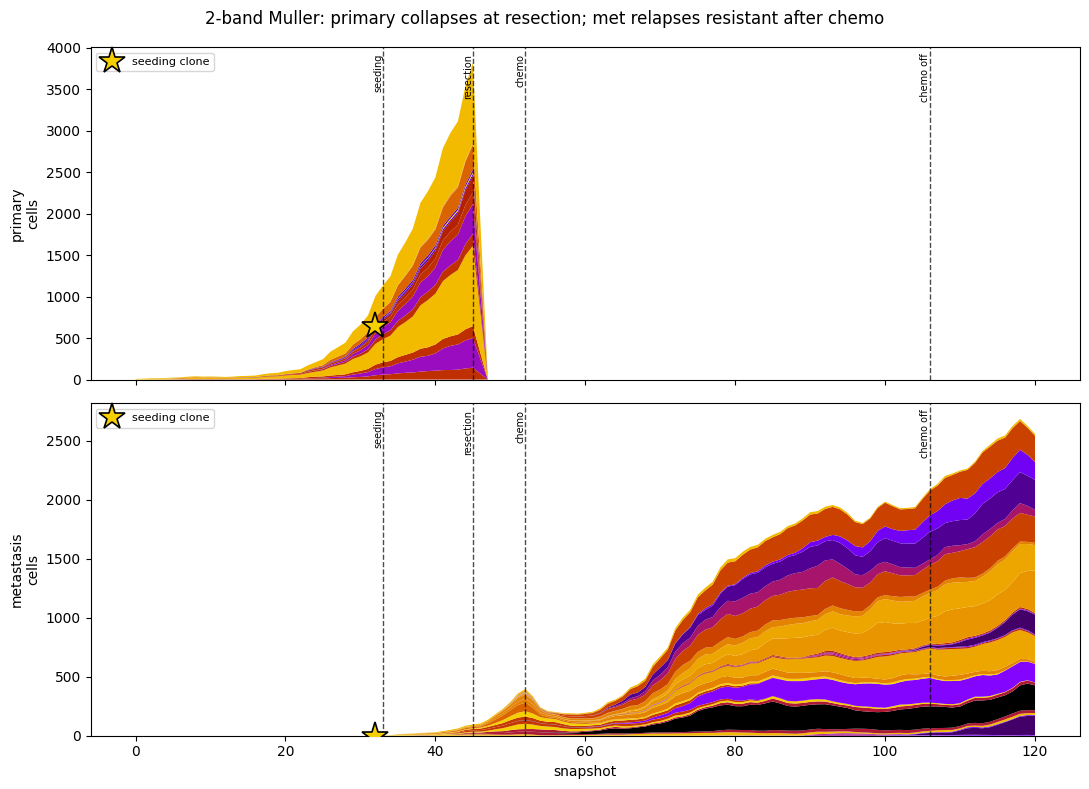

In [3]:
t.plot_muller_compartments(by_drivers=True, min_freq=0.05, mark_generations=mk)
plt.suptitle('2-band Muller: primary collapses at resection; met relapses resistant after chemo')
plt.tight_layout(); plt.show()

## Which primary population seeds the metastasis?
A single primary Muller with the met-seeding clones highlighted (red) against the rest (grey). The
founders are **thin minor bands**, never the dominant clones — so inference from the met's data
alone would misread the primary's clonal structure (the metastasis analogue of *sample trees are
not phylogenies*).

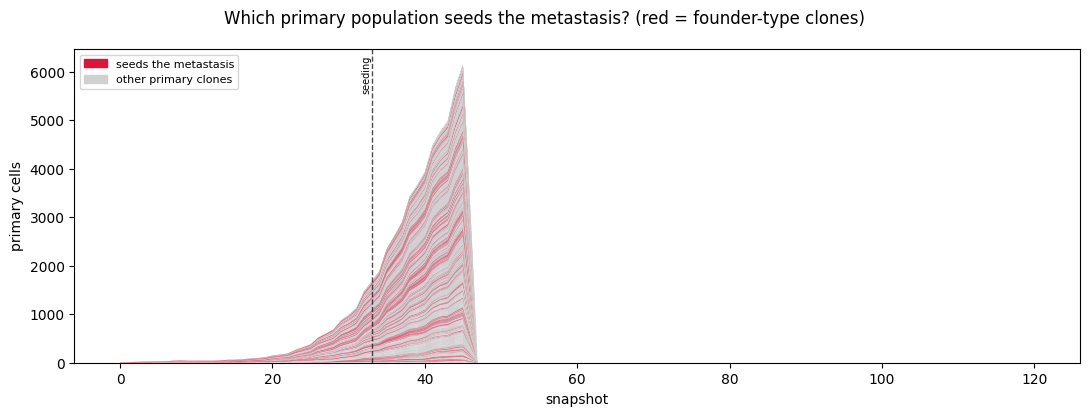

In [4]:
t.plot_muller_founders(mark_generations=[(marks.get('seeding', 0), 'seeding')])
plt.suptitle('Which primary population seeds the metastasis? (red = founder-type clones)')
plt.tight_layout(); plt.show()

## Spatial clone series across the arc
The same clone colormap, now in space, at each stage: the primary duct field at met-seeding and
just before resection, then the metastatic deposit at seeding (a single deme at the vessel),
before resection, before chemo, at the end of chemo, and at the end of the simulation. A deme is
coloured by its dominant **cancer** clone where any cancer is present (so a minority deposit stays
visible), else by its resident tissue — so the founding clone is traceable from the primary all the
way through the met's growth, regression and resistant relapse.

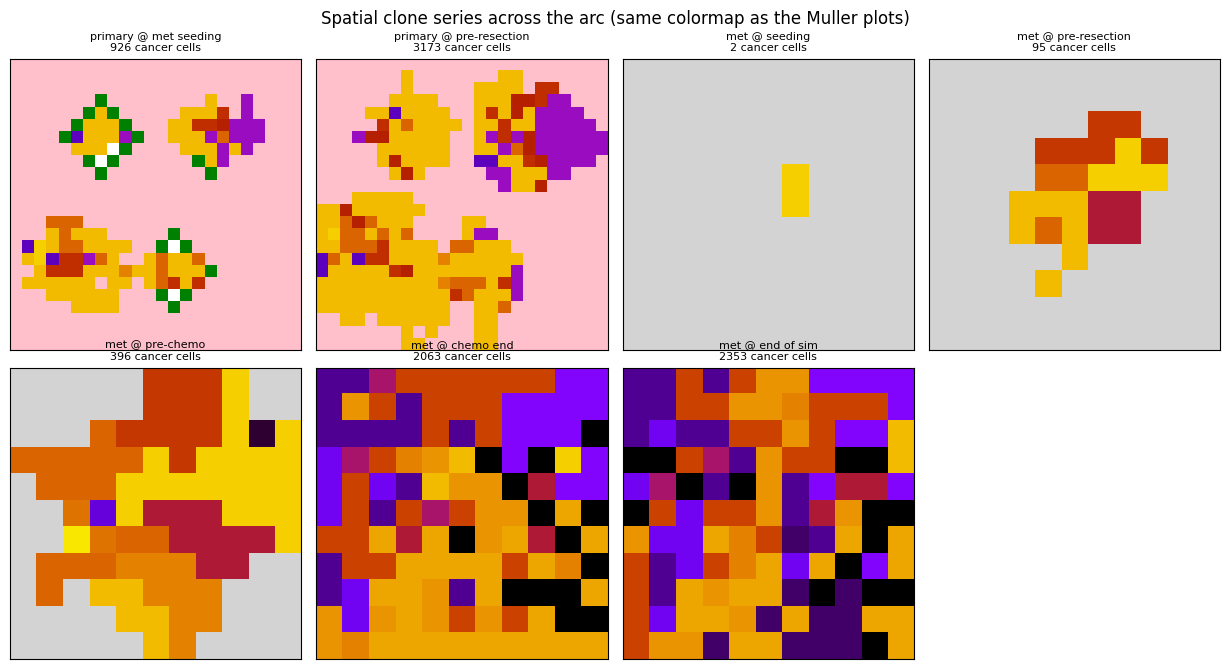

In [5]:
from iscc.tumor import viz
panels = [('seeding', 'primary', 'primary @ met seeding'),
          ('pre_resection', 'primary', 'primary @ pre-resection'),
          ('seeding', 'met', 'met @ seeding'),
          ('pre_resection', 'met', 'met @ pre-resection'),
          ('pre_chemo', 'met', 'met @ pre-chemo'),
          ('chemo_end', 'met', 'met @ chemo end'),
          ('end', 'met', 'met @ end of sim')]
viz.plot_clone_grid_series(t, panels, driver_map=t._functional_signatures(), min_freq=0.05, ncols=4)
plt.suptitle('Spatial clone series across the arc (same colormap as the Muller plots)')
plt.tight_layout(); plt.show()

## Chemotherapy toxicity on normal tissue
`toxicity` is off-target *anything*: total normal (host / epithelial / stromal / immune) cells drop
at resection (the primary is removed) and then decline under the chemo window as the drug kills the
met's normal host tissue — the systemic side-effect a spatial, cell-resolved model can quantify.

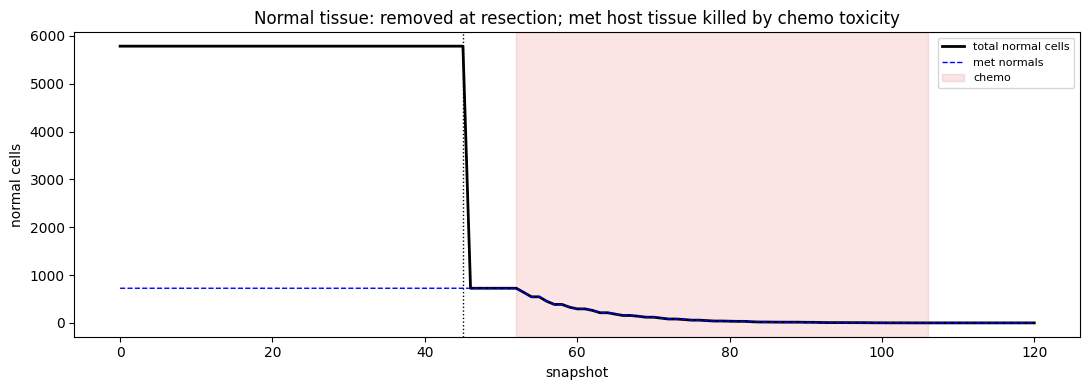

In [6]:
prim_n, met_n = bs.normal_totals(t)
x = np.arange(len(prim_n))
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(x, prim_n + met_n, 'k-', lw=2, label='total normal cells')
ax.plot(x, met_n, 'b--', lw=1, label='met normals')
ax.axvspan(marks['chemo_start'], marks['chemo_end'], color='tab:red', alpha=0.12, label='chemo')
ax.axvline(marks['resection'], color='k', ls=':', lw=1)
ax.set_xlabel('snapshot'); ax.set_ylabel('normal cells'); ax.legend(fontsize=8)
ax.set_title('Normal tissue: removed at resection; met host tissue killed by chemo toxicity')
plt.tight_layout(); plt.show()